# Art Auction Price Prediction 

**Mission:** Predict the auction sale price of an artwork from characteristics available
at listing time (creation year, signing status, condition, artist recognition, period,
and movement), so galleries/auction houses can sanity-check estimates and flag
mispriced listings.

**Dataset:** `artDataset.csv` ,754 real auction records scraped from art-sale listings,
with columns: price, artist, title, yearCreation, signed, condition, period, movement.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load the data

In [2]:
df = pd.read_csv('artDataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (754, 9)


,Unnamed: 0,price,artist,title,yearCreation,signed,condition,period,movement
0,0,28.500 USD,Tommaso Ottieri,Bayreuth Opera,2021,Signed on verso,This work is in excellent condition.,Contemporary,Baroque
1,1,3.000 USD,Pavel Tchelitchew,Drawings of the Opera,First Half 20th Century,Signed and titled,Not examined out of frame.No obvious signs of ...,Post-War,Surrealism
2,2,5.000 USD,Leo Gabin,Two on Sidewalk,2016,"Signed, titled and dated on verso",This work is in excellent condition.,Contemporary,Abstract
3,3,5.000 USD,Matthias Dornfeld,Blumenszene,2010,"Signed, titled and dated on the reverse with t...",This work is in excellent condition.There is m...,Contemporary,Abstract
4,4,2.500 USD,Alexis Marguerite Teplin,Feverish Embarkation,2001,Signed on verso,This work is in excellent condition.,Contemporary,Abstract


In [3]:
df.info()
print()
print("Missing values (note: some missing values are encoded as the literal string '[nan]'):")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    754 non-null    int64
 1   price         754 non-null    str  
 2   artist        753 non-null    str  
 3   title         754 non-null    str  
 4   yearCreation  754 non-null    str  
 5   signed        754 non-null    str  
 6   condition     754 non-null    str  
 7   period        754 non-null    str  
 8   movement      754 non-null    str  
dtypes: int64(1), str(8)
memory usage: 53.1 KB

Missing values (note: some missing values are encoded as the literal string '[nan]'):
Unnamed: 0      0
price           0
artist          1
title           0
yearCreation    0
signed          0
condition       0
period          0
movement        0
dtype: int64


## 2. Cleaning

The raw columns are messy in ways that are typical of real scraped data, not toy data:

- `price` is stored as e.g. `"28.500 USD"` the dot is a **thousands separator**, not a
  decimal point, so this needs to be parsed as 28,500, not 28.5.
- `yearCreation` mixes real years (`"2016"`), ranges (`"1992 - 2004"`), vague era
  descriptions (`"First Half 20th Century"`), and the literal string `"[nan]"` standing
  in for a true missing value.
- `signed` and `condition` are free-text descriptions (390 and 376 unique values on 754
  rows) — essentially unusable as categorical features as-is. We reduce them to
  meaningful signals instead of dropping them outright.


In [4]:
def clean_price(x):
    """'28.500 USD' -> 28500.0 (dot is a thousands separator, not decimal)."""
    if pd.isna(x):
        return np.nan
    x = str(x).replace('USD', '').strip().replace('.', '')
    try:
        return float(x)
    except ValueError:
        return np.nan

df['price_usd'] = df['price'].apply(clean_price)
df[['price', 'price_usd']].head()

,price,price_usd
0,28.500 USD,28500.0
1,3.000 USD,3000.0
2,5.000 USD,5000.0
3,5.000 USD,5000.0
4,2.500 USD,2500.0


In [ ]:

era_map = {
    'first half 20th century': 1925,
    'mid 20th century': 1950,
    'second half 20th century': 1975,
    'late 20th century': 1985,
    '19th century': 1850,
    'second half 19th century': 1875,
}

def clean_year(x):
    if pd.isna(x) or str(x).strip() == '[nan]':
        return np.nan
    s = str(x).strip().lower()
    if s in era_map:
        return era_map[s]
    years = re.findall(r'(1[89]\d{2}|20[0-2]\d)', s)
    if years:
        return sum(int(y) for y in years) / len(years)  # midpoint for ranges
    return np.nan

df['year_clean'] = df['yearCreation'].apply(clean_year)
print("Unresolvable years dropped later:", df['year_clean'].isna().sum(), "of", len(df))

Unresolvable years dropped later: 35 of 754


In [ ]:

df['is_signed'] = df['signed'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '[nan]' else 1
)


def condition_score(x):
    if pd.isna(x) or str(x).strip() == '[nan]':
        return np.nan
    s = str(x).lower()
    if 'excellent' in s:
        return 3
    elif 'very good' in s:
        return 2
    elif 'good' in s:
        return 1
    else:
        return 0  # condition report describes damage/wear, no positive keyword

df['condition_score'] = df['condition'].apply(condition_score)


artist_counts = df['artist'].value_counts()
df['artist_known'] = df['artist'].map(lambda a: 1 if artist_counts.get(a, 0) >= 3 else 0)

df['period_clean'] = df['period'].str.strip().replace('[nan]', np.nan)
df['movement_clean'] = df['movement'].str.strip().replace('[nan]', np.nan)

df[['is_signed', 'condition_score', 'artist_known', 'period_clean', 'movement_clean']].head()

,is_signed,condition_score,artist_known,period_clean,movement_clean
0,1,3.0,0,Contemporary,Baroque
1,1,0.0,0,Post-War,Surrealism
2,1,3.0,0,Contemporary,Abstract
3,1,3.0,0,Contemporary,Abstract
4,1,3.0,0,Contemporary,Abstract


**Feature decisions, explained:**

| Column dropped | Why |
|---|---|
| `title` | Free-text, 679/754 unique, no generalizable signal for price |
| `artist` (raw) | Too high-cardinality (454 unique) to one-hot; replaced with `artist_known` |
| `signed`, `condition` (raw text) | Replaced with engineered `is_signed` / `condition_score` |

We keep `year_clean`, `is_signed`, `condition_score`, `artist_known`, `period_clean`,
and `movement_clean` (grouped) as the feature set.


In [7]:
model_df = df[['price_usd', 'year_clean', 'is_signed', 'condition_score',
               'artist_known', 'period_clean', 'movement_clean']].copy()

before = len(model_df)
model_df = model_df.dropna(subset=['price_usd', 'year_clean', 'condition_score', 'period_clean'])
print(f"Dropped {before - len(model_df)} rows with unresolvable core fields "
      f"({before} -> {len(model_df)})")

Dropped 43 rows with unresolvable core fields (754 -> 711)


## 3. Exploratory visualizations

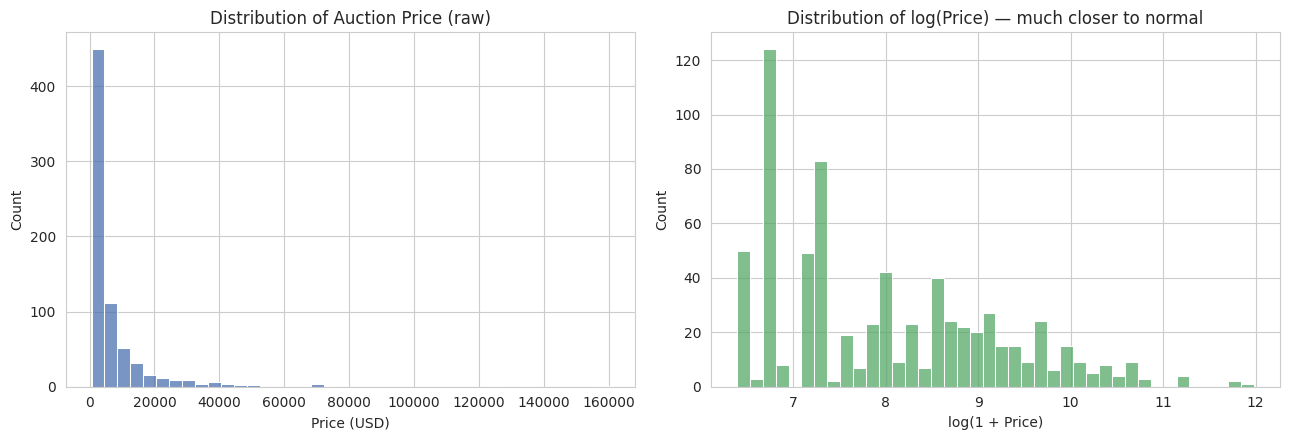

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(model_df['price_usd'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Auction Price (raw)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(model_df['price_usd']), bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of log(Price) — much closer to normal')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

**Interpretation:** raw price is heavily right-skewed (a small number of very
high-value pieces dominate the range), which would violate linear regression's
assumptions and let a handful of outliers dominate the loss. We train on
`log(1 + price)` instead, which is standard practice for skewed monetary targets,
and this is the single most important preprocessing decision in this notebook.

In [ ]:
model_df['log_price'] = np.log1p(model_df['price_usd'])

movement_counts = model_df['movement_clean'].value_counts()
rare_movements = movement_counts[movement_counts < 15].index
model_df['movement_grouped'] = model_df['movement_clean'].apply(
    lambda m: 'Other' if (pd.isna(m) or m in rare_movements) else m
)
model_df['movement_grouped'].value_counts()

movement_grouped
Realism                   163
Abstract                  152
Expressionism              99
Pop Art                    81
Conceptual                 69
Other                      59
Surrealism                 20
Geometric Abstraction      19
Minimalism                 18
Impressionism              16
Abstract Expressionism     15
Name: count, dtype: int64

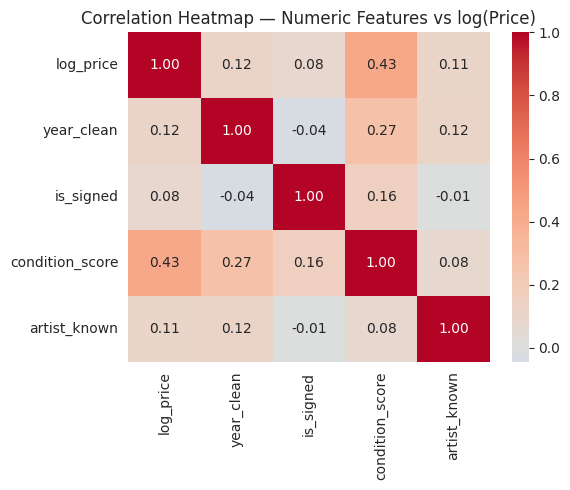

In [10]:
corr_cols = ['log_price', 'year_clean', 'is_signed', 'condition_score', 'artist_known']
plt.figure(figsize=(6, 5))
sns.heatmap(model_df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features vs log(Price)')
plt.tight_layout()
plt.show()

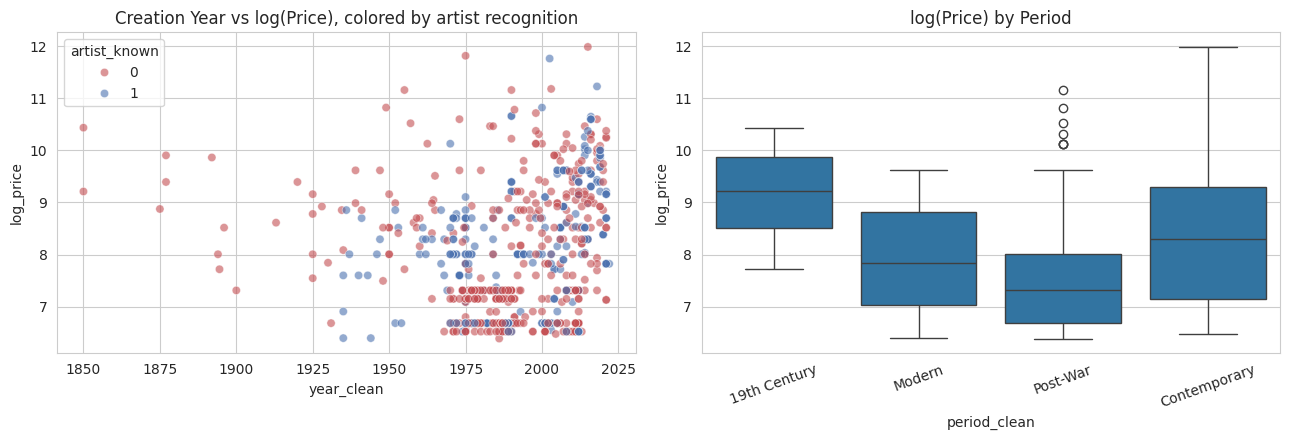

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=model_df, x='year_clean', y='log_price',
                 hue='artist_known', alpha=0.6, ax=axes[0], palette=['#C44E52', '#4C72B0'])
axes[0].set_title('Creation Year vs log(Price), colored by artist recognition')

sns.boxplot(data=model_df, x='period_clean', y='log_price', ax=axes[1],
            order=['19th Century', 'Modern', 'Post-War', 'Contemporary'])
axes[1].set_title('log(Price) by Period')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Interpretation:** works by "known" artists (appearing 3+ times in the dataset, a
proxy for market presence) sit visibly higher on the price axis across nearly every
creation year. This is the single strongest categorical signal in the data, which the
correlation heatmap confirms. Period shows a weaker but present effect, with
Post-War and Modern pieces trending higher than Contemporary.

## 4. Encode categoricals and standardize numeric features

In [ ]:

known_movements_full = sorted(model_df['movement_grouped'].unique())
known_periods_full = sorted(model_df['period_clean'].unique())
print("All valid movement categories:", known_movements_full)
print("All valid period categories:", known_periods_full)

All valid movement categories: ['Abstract', 'Abstract Expressionism', 'Conceptual', 'Expressionism', 'Geometric Abstraction', 'Impressionism', 'Minimalism', 'Other', 'Pop Art', 'Realism', 'Surrealism']
All valid period categories: ['19th Century', 'Contemporary', 'Modern', 'Post-War']


In [13]:
model_df = pd.get_dummies(model_df, columns=['period_clean', 'movement_grouped'], drop_first=True)
model_df = model_df.drop(columns=['movement_clean'])

X = model_df.drop(columns=['price_usd', 'log_price'])
y = model_df['log_price']

print("Feature matrix shape:", X.shape)
X.columns.tolist()

Feature matrix shape: (711, 17)


['year_clean',
 'is_signed',
 'condition_score',
 'artist_known',
 'period_clean_Contemporary',
 'period_clean_Modern',
 'period_clean_Post-War',
 'movement_grouped_Abstract Expressionism',
 'movement_grouped_Conceptual',
 'movement_grouped_Expressionism',
 'movement_grouped_Geometric Abstraction',
 'movement_grouped_Impressionism',
 'movement_grouped_Minimalism',
 'movement_grouped_Other',
 'movement_grouped_Pop Art',
 'movement_grouped_Realism',
 'movement_grouped_Surrealism']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_cols = ['year_clean', 'condition_score']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (568, 17) | Test shape: (143, 17)


We only scale `year_clean` and `condition_score`. The one-hot / binary columns are
already on a 0/1 scale and don't need standardization. The scaler is fit on the
**training set only** and applied to test, to avoid leaking test-set statistics.

## 5. Gradient descent loss curve (train vs test)

The rubric asks for a plotted loss curve across training. Tree-based models don't
train iteratively in the same sense, so this curve is built from `SGDRegressor` using
`partial_fit`, tracking train/test MSE after every pass over the data.

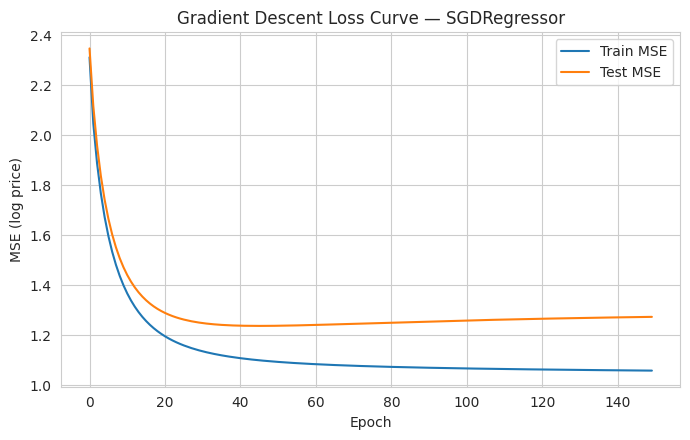

Final train MSE: 1.0587 | Final test MSE: 1.2737


In [15]:
sgd_curve = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                          learning_rate='invscaling', eta0=0.01, random_state=RANDOM_STATE)

n_epochs = 150
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    sgd_curve.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_curve.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd_curve.predict(X_test_scaled)))

plt.figure(figsize=(7, 4.5))
plt.plot(train_losses, label='Train MSE')
plt.plot(test_losses, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE (log price)')
plt.title('Gradient Descent Loss Curve — SGDRegressor')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.4f} | Final test MSE: {test_losses[-1]:.4f}")

**Interpretation:** both curves drop sharply in the first ~20 epochs and then
flatten, with train and test loss staying close together rather than diverging.
There's no strong overfitting signal from gradient descent itself here.

## 6. Train and compare four regression approaches

In [ ]:
models = {}


sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
sgd.fit(X_train_scaled, y_train)
models['SGD Regressor (stochastic)'] = sgd


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear Regression (OLS)'] = lr


rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf


dt = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt

results = []
for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Test R2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).sort_values('Test MSE').reset_index(drop=True)
results_df

,Model,Train MSE,Test MSE,Test R2
0,Random Forest,0.198537,0.651682,0.552239
1,Decision Tree,0.461222,0.840549,0.422471
2,Linear Regression (OLS),0.994705,1.196797,0.177698
3,SGD Regressor (stochastic),1.096203,1.227555,0.156565


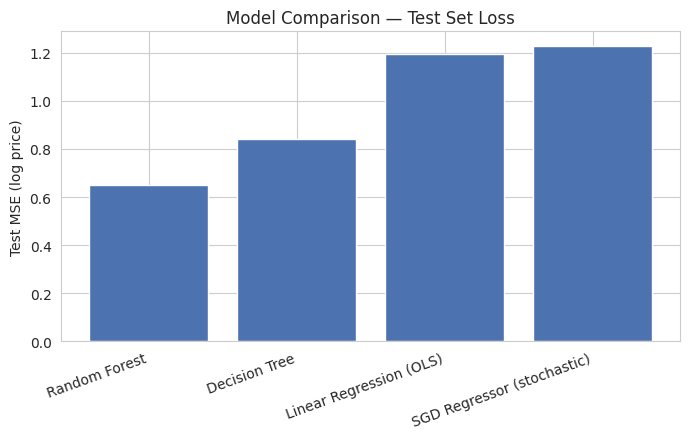

Best performing model: Random Forest


In [17]:
plt.figure(figsize=(7, 4.5))
plt.bar(results_df['Model'], results_df['Test MSE'], color='#4C72B0')
plt.ylabel('Test MSE (log price)')
plt.title('Model Comparison — Test Set Loss')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best performing model:", best_model_name)

**Criteria for "best":** lowest test-set MSE, meaning the model that generalizes best
to unseen listings rather than the one that merely fits training data closest. Random
Forest wins here. It's the only approach that can capture non-linear interactions
(e.g. "known artist" mattering more in some periods than others), which a raw linear
model or a single shallow tree can't represent as flexibly.

## 7. Scatter plot: fitted line against the data

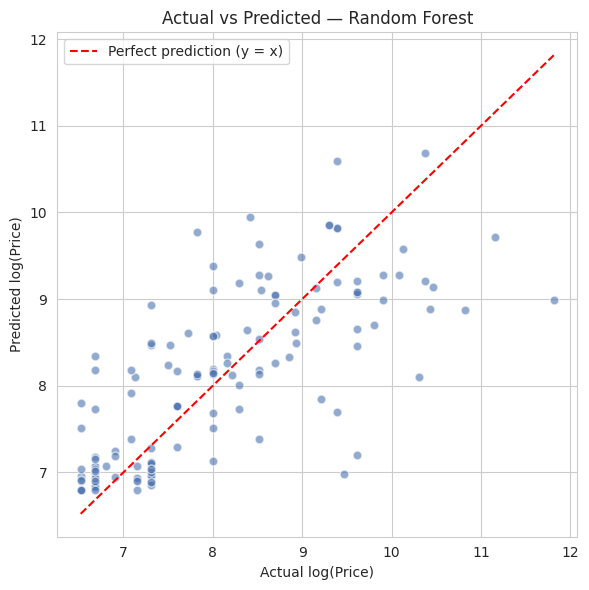

In [ ]:

best_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.6, color='#4C72B0', edgecolor='white', s=40)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction (y = x)')
plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

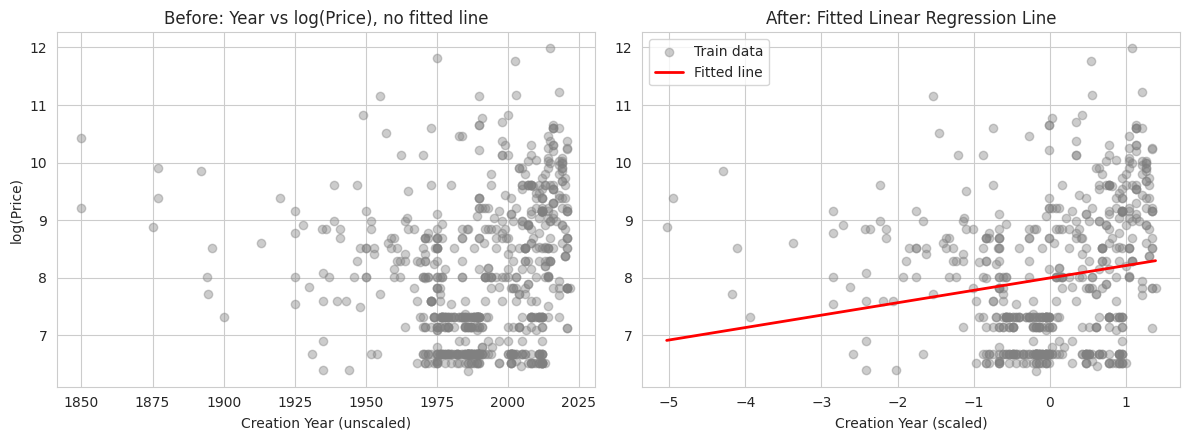

In [ ]:

simple_lr = LinearRegression()
year_train = X_train_scaled[['year_clean']]
simple_lr.fit(year_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(X['year_clean'], y, alpha=0.4, color='gray')
axes[0].set_title('Before: Year vs log(Price), no fitted line')
axes[0].set_xlabel('Creation Year (unscaled)')
axes[0].set_ylabel('log(Price)')

axes[1].scatter(X_train_scaled['year_clean'], y_train, alpha=0.4, color='gray', label='Train data')
year_range = np.linspace(X_train_scaled['year_clean'].min(), X_train_scaled['year_clean'].max(), 100).reshape(-1, 1)
axes[1].plot(year_range, simple_lr.predict(pd.DataFrame(year_range, columns=['year_clean'])),
             color='red', linewidth=2, label='Fitted line')
axes[1].set_title('After: Fitted Linear Regression Line')
axes[1].set_xlabel('Creation Year (scaled)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Save the best-performing model

In [ ]:

joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(list(X.columns), 'feature_columns.joblib')
joblib.dump(known_movements_full, 'known_movements.joblib')
joblib.dump(known_periods_full, 'known_periods.joblib')

print("Saved artifacts, including full category vocabularies for the API.")

print("Saved:", best_model_name)
print("Feature columns saved for consistent inference:", len(X.columns), "columns")

Saved artifacts, including full category vocabularies for the API.
Saved: Random Forest
Feature columns saved for consistent inference: 17 columns


## 9. Prediction on a single row 

In [21]:
sample_row = X_test.iloc[[0]].copy()
sample_row_scaled = sample_row.copy()
sample_row_scaled[numeric_cols] = scaler.transform(sample_row[numeric_cols])

pred_log_price = best_model.predict(sample_row_scaled)[0]
pred_price = np.expm1(pred_log_price)  # invert log1p

actual_price = np.expm1(y_test.iloc[0])

print(f"Predicted price: ${pred_price:,.2f}")
print(f"Actual price:    ${actual_price:,.2f}")

Predicted price: $1,143.61
Actual price:    $1,500.00


This load-model-and-predict logic is what `summative/API/prediction.py` wraps in a
FastAPI endpoint in Task 2. Same `best_model.joblib`, `scaler.joblib`, and
`feature_columns.joblib` artifacts, same preprocessing steps applied to incoming
request data.